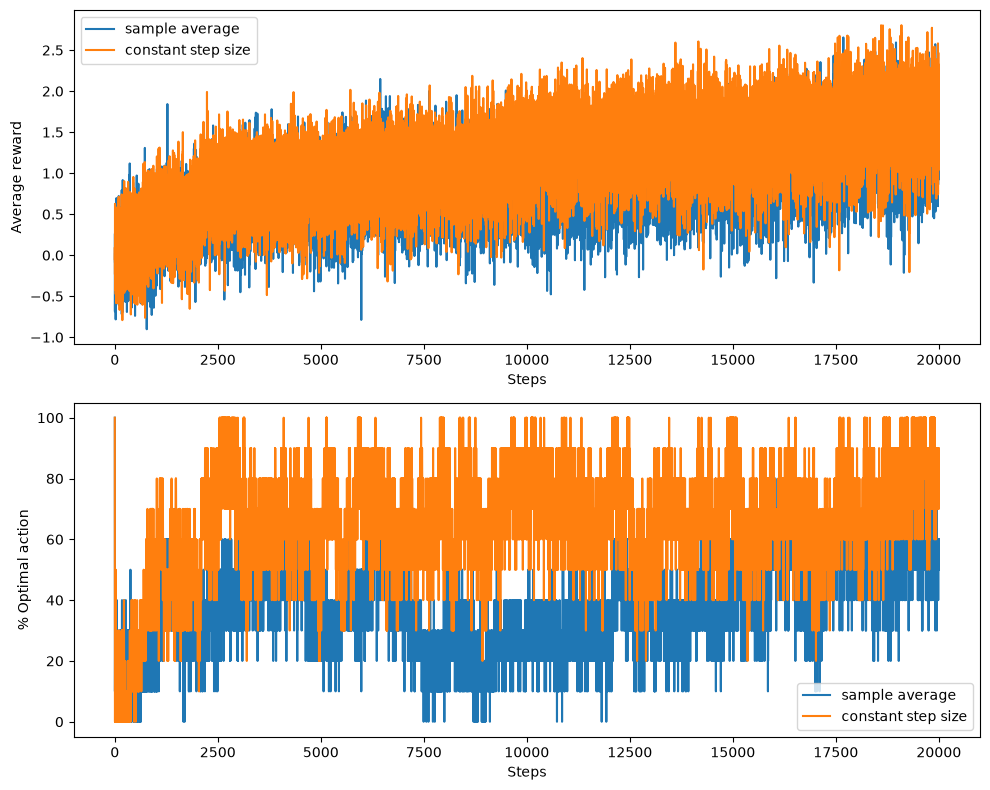

In [ ]:
# Exercise 2.5: non-stationary 10-armed bandit
# Comparing sample average vs constant step size (alpha=0.1) on a non-stationary bandit where true rewards drift due to random walk (mean=0, std=0.01 per step).
# epsilon=0.1, 20000 steps, 200 runs.
# Result: Constant step size tracks changes better.
import numpy as np
import matplotlib.pyplot as plt
import random

def bandit(actions, true_rewards, runs):
    rewards = np.random.normal(true_rewards[np.arange(runs), actions], 1) 
    return rewards

def egreedy(true_rewards, runs, val_est, action_counts, epsilon, all_optimals, step):
    explore = np.random.random(size = runs) < epsilon
    random_actions = np.random.randint(0,9, size = runs)

    max_vals = val_est.max(axis = 1, keepdims = True)
    # if val_est is n x 3
    # max_vals = [[a],
    #             [b],
    #             [c]]

    best_actions = val_est == max_vals
    # if val_est is 3 x 3
    # best_actions = [[x1_1 == a, x1_2 == a, x1_3 == a],
    #                 [x2_1 == b, x2_2 == b, x2_3 == b],
    #                 [x3_1 == c, x3_2 == c, x3_3 == c]]
    # a matrix where each row the best actions = True

    random = np.random.random(best_actions.shape)
    # random = [[0.2, 0.9, 0.3],
    #           [0.1, 0.4, 0.5],
    #           [0.5, 0.3, 0.6]]

    random[~best_actions] = -1
    # ~best_actions is best_actions where every element = !element
    # so ~best_actions is a matrix where each row the actions that arent the best = True
    # random[~best_actions] = -1 gets every element in random where ~best_actions is True, and sets them to -1

    greedy_actions = np.argmax(random, axis = 1)

    actions = np.where(explore, random_actions, greedy_actions)

    rewards = bandit(actions, true_rewards, runs)

    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
    rewards.append(reward)
    if true_rewards[action] == max(true_rewards):
        optimal_choice.append(100)
    else:
        optimal_choice.append(0)

def step_size(true_rewards,value_estimates,action_chosen,epsilon,step_size, rewards,optimal_choice):
    if random.random() < epsilon:
        index = random.randint(0,9)
        action = index
    else:
        greediest_value = max(value_estimates)
        greedy_actions = []
        for action, value in enumerate(value_estimates):
            if value == greediest_value:
                greedy_actions.append(action)
        action = random.choice(greedy_actions)
    reward = bandit(action,true_rewards)
    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
    rewards.append(reward)
    if true_rewards[action] == max(true_rewards):
        optimal_choice.append(100)
    else:
        optimal_choice.append(0)

def main():
    

    steps = 20000
    runs = 10
    epsilon = 0.1
    constant_step_size = 0.1
    avg_rewards = np.zeros((runs, steps))
    optimal_pct = np.zeros((runs, steps))
    avg_rewards_alt = np.zeros((runs, steps))
    optimal_pct_alt = np.zeros((runs, steps))

    true_rewards  = np.zeros((runs, 10))
    
    egreedy_val_est = np.zeros((runs, 10))
    egreedy_action_counts = np.zeros((runs, 10))
    agreedy_val_est = np.zeros((runs, 10))
    agreedy_action_counts = np.zeros((runs, 10))

    egreedy_all_run_rewards = np.zeros((runs, steps))
    egreedy_all_run_optimals = np.zeros((runs, steps))

    agreedy_run_rewards = np.zeros((runs, steps))
    agreedy_run_optimals = np.zeros((runs, steps))

    for step in range(1, steps + 1):
        egreedy_all_run_rewards, egreedy_all_run_optimals = egreedy(true_rewards, runs, egreedy_val_est, egreedy_action_counts, epsilon, egreedy_all_run_rewards, egreedy_all_run_optimals, step)


    for run in range(1, runs + 1):
        true_rewards  = np.zeros(10)

        value_estimates = [0,0,0,0,0,0,0,0,0,0]
        action_chosen = [0,0,0,0,0,0,0,0,0,0]

        alt_value_estimates = [0,0,0,0,0,0,0,0,0,0]
        alt_action_chosen = [0,0,0,0,0,0,0,0,0,0]

        rewards = []
        optimal_choice = []

        alt_rewards = []
        alt_optimal_choice = []

        for step in range(1,steps + 1):
            egreedy(true_rewards, value_estimates, action_chosen, epsilon, rewards, optimal_choice)
            step_size(true_rewards, alt_value_estimates, alt_action_chosen, epsilon, constant_step_size, alt_rewards, alt_optimal_choice)

            true_rewards += np.random.normal(0, 0.01, 10)

        avg_rewards += rewards
        optimal_pct += optimal_choice
        avg_rewards_alt += alt_rewards
        optimal_pct_alt += alt_optimal_choice

    avg_rewards /= runs
    optimal_pct /= runs
    avg_rewards_alt /= runs
    optimal_pct_alt /= runs

    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(avg_rewards, label='sample average')
    ax1.plot(avg_rewards_alt, label='constant step size')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Average reward')
    ax1.legend()

    ax2.plot(optimal_pct, label='sample average')
    ax2.plot(optimal_pct_alt, label='constant step size')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('% Optimal action')
    ax2.legend()

    plt.tight_layout()
    plt.show()

main()